# Notebook 18 — Gradient-Based Adversarial Robustness (FGSM / PGD / C&W)

**Future line LF3 -> implemented.** NB14 measured robustness with a
*grid search* over severity, which represents a **weak** threat: a black-box
attacker with no gradient access. Here we expose the detector to the
**standard white-box threat**: an attacker who **knows the detector** and
exploits its gradient to craft the perturbation that evades it.

- **FGSM** (Goodfellow et al., 2015): a single step along the sign of the gradient.
- **PGD** (Madry et al., 2018): iterative FGSM projected onto an
  $\ell_\infty$ ball — the reference attack.
- **C&W** (Carlini & Wagner, 2017): optimization with an $\ell_2$ penalty.
- **Adversarial training**: a defense based on retraining with PGD examples.
- **Transferability / ensemble**: how much combining several detectors raises the
  cost of evasion (this justifies the *stacking* in NB10).

> **Realistic threat model:** the attacker controls only the **reported
> measurements** (sensors and derived features), not the clock. The perturbation
> is therefore **masked**: the cyclical features (`hour_*`, `dow_*`) remain frozen.

## 0. Setup and target detector

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore'); np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 4.5); plt.rcParams['font.size'] = 11
import tfg_common as C

d = C.build_matrices(mode='full')
X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
y_val, y_test = d['y_val'], d['y_test']
n_features = d['n_features']; feat_names = d['feat_names']
sev_test = d['df_test']['severity'].values   # per-row severity, aligned with X_test
print('Data:', X_train.shape)

Data: (1300061, 17)


In [2]:
def train_detector(seed, epochs=6):
    tf.random.set_seed(seed)
    m = C.build_dense_ae(n_features, bottleneck=4)
    m.fit(X_train, X_train, epochs=epochs, batch_size=1024, validation_split=0.1, verbose=0)
    mse_val = (X_val - m.predict(X_val, batch_size=8192, verbose=0)) ** 2
    aucs = np.array([roc_auc_score(y_val, mse_val[:, j]) if len(np.unique(mse_val[:, j])) > 1
                     else 0.5 for j in range(n_features)])
    w = np.maximum(aucs - 0.5, 0); w = w / (w.sum() + 1e-10)
    return m, w.astype('float32')

t0 = time.time(); target, weights = train_detector(42)
print(f'Detector trained in {time.time()-t0:.1f}s')

def score_np(model, X, w):
    rec = model.predict(X, batch_size=8192, verbose=0)
    return ((X - rec) ** 2 * w[None, :]).sum(1)

sv = score_np(target, X_val, weights)
thr, _ = C.calibrate_threshold(y_val, sv, beta=1.0)
yv = (sv > thr).astype(int); Wb, Kb = C.calibrate_WK(y_val, yv)
st = score_np(target, X_test, weights)
base = C.evaluate(y_test, st, thr, Wb, Kb)
print(f"Clean detector -> F1={base['f1']:.4f}  AUC-PR={base['auc_pr']:.4f}  threshold={thr:.4f}")

2026-06-18 16:32:14.141048: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-18 16:32:14.143097: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-18 16:32:14.143108: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1781793134.150056 1626758 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781793134.150763 1626758 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-06-18 16:32:15.690737: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Detector trained in 68.4s
Clean detector -> F1=0.7930  AUC-PR=0.8054  threshold=1.1191


## 1. Gradient attacks

The detector score is $s(x)=\sum_j w_j\,(x_j-\mathrm{dec}(\mathrm{enc}(x))_j)^2$,
which is differentiable with respect to the input. An evasive attacker
**minimizes** it to drop below the threshold. The perturbation is bounded to an
$\ell_\infty$ ball of radius $\epsilon$ and applied only to the controllable
features (via the mask). The score weights are passed as an **explicit argument**
so that each attack uses the weights of the correct model.

In [3]:
frozen = {'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'}
mask = np.array([0.0 if f in frozen else 1.0 for f in feat_names], 'float32')
MASK = tf.constant(mask)
print('Frozen features:', [f for f in feat_names if f in frozen])

@tf.function(reduce_retracing=True)
def score_tf(model, X, w):
    rec = model(X, training=False)
    return tf.reduce_sum(w * tf.square(X - rec), axis=1)

def attack(model, X0, eps, w, steps=20, mode='evade', method='pgd'):
    X0 = tf.constant(X0); w = tf.constant(w)
    sign = -1.0 if mode == 'evade' else 1.0
    if method == 'fgsm':
        with tf.GradientTape() as t:
            t.watch(X0); s = tf.reduce_sum(score_tf(model, X0, w))
        g = t.gradient(s, X0)
        Xa = X0 + sign * eps * tf.sign(g) * MASK
        return tf.clip_by_value(Xa, X0 - eps, X0 + eps).numpy()
    Xa = tf.identity(X0); alpha = eps / 4.0
    for _ in range(steps):
        with tf.GradientTape() as t:
            t.watch(Xa); s = tf.reduce_sum(score_tf(model, Xa, w))
        g = t.gradient(s, Xa)
        Xa = Xa + sign * alpha * tf.sign(g) * MASK
        Xa = tf.clip_by_value(Xa, X0 - eps, X0 + eps)
    return Xa.numpy()

def cw_l2(model, X0, w, c=1.0, steps=60, lr=0.05, mode='evade'):
    X0 = tf.constant(X0); w = tf.constant(w)
    delta = tf.Variable(tf.zeros_like(X0)); opt = tf.optimizers.Adam(lr)
    sign = 1.0 if mode == 'evade' else -1.0
    for _ in range(steps):
        with tf.GradientTape() as t:
            Xa = X0 + delta * MASK
            obj = sign * c * tf.reduce_sum(score_tf(model, Xa, w)) + tf.reduce_sum(tf.square(delta))
        g = t.gradient(obj, delta); opt.apply_gradients([(g, delta)])
    return (X0 + delta * MASK).numpy()

def detect_rate(model, X, w, threshold):
    return float((((X - model.predict(X, batch_size=8192, verbose=0)) ** 2 * w).sum(1) > threshold).mean())

Frozen features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


## 2. Robustness curve against gradient perturbations

We draw attack windows from the test set that the detector **does detect**, and
measure the detection rate after the attack for increasing $\epsilon$ (expressed
in units of the `RobustScaler` IQR). PGD is stronger than FGSM. The detector
proves **reasonably robust** in feature space: even at large budgets, evasion
remains partial.

Base detected attacks: 76,395 | sample used: 3000
  eps=0.00  detection FGSM=1.000  PGD=1.000
  eps=0.05  detection FGSM=0.992  PGD=0.993
  eps=0.10  detection FGSM=0.985  PGD=0.984
  eps=0.20  detection FGSM=0.970  PGD=0.969
  eps=0.30  detection FGSM=0.959  PGD=0.954
  eps=0.50  detection FGSM=0.941  PGD=0.925
  eps=0.80  detection FGSM=0.931  PGD=0.888
  eps=1.20  detection FGSM=0.939  PGD=0.836
  C&W: detection=0.958  max Linf perturbation=3.473


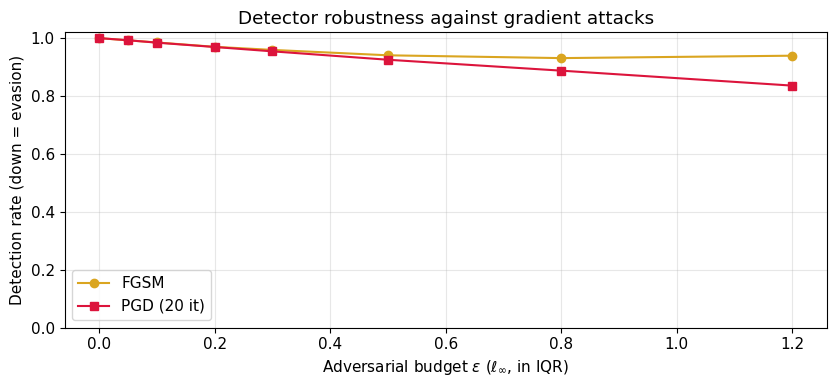

In [4]:
atk_idx = np.where((y_test == 1) & (st > thr))[0]
sel = np.random.choice(atk_idx, min(3000, len(atk_idx)), replace=False)
Xatk = X_test[sel]; sev_sel = sev_test[sel]
print(f'Base detected attacks: {len(atk_idx):,} | sample used: {len(sel)}')

eps_grid = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.2]
rob = {'fgsm': [], 'pgd': []}
for eps in eps_grid:
    for method in ['fgsm', 'pgd']:
        Xa = Xatk if eps == 0 else attack(target, Xatk, eps, weights, method=method, mode='evade')
        rob[method].append(detect_rate(target, Xa, weights, thr))
    print(f'  eps={eps:.2f}  detection FGSM={rob["fgsm"][-1]:.3f}  PGD={rob["pgd"][-1]:.3f}')

Xcw = cw_l2(target, Xatk, weights, c=2.0, mode='evade')
det_cw = detect_rate(target, Xcw, weights, thr); linf_cw = float(np.abs(Xcw - Xatk).max())
print(f'  C&W: detection={det_cw:.3f}  max Linf perturbation={linf_cw:.3f}')

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(eps_grid, rob['fgsm'], 'o-', label='FGSM', color='goldenrod')
ax.plot(eps_grid, rob['pgd'], 's-', label='PGD (20 it)', color='crimson')
ax.set(xlabel=r'Adversarial budget $\epsilon$ ($\ell_\infty$, in IQR)',
       ylabel='Detection rate (down = evasion)',
       title='Detector robustness against gradient attacks'); ax.set_ylim(0, 1.02)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'adversarial_robustness_gradient.png'), dpi=130); plt.show()

## 3. Evasion by severity: small thefts are easier to hide

Which attacks are evaded most easily? At a fixed budget, we measure the fraction
of attacks that go undetected, broken down by severity. The economic
interpretation is direct: **low-severity** attacks (modest theft) sit closer to
normal consumption and are therefore **more evadable**.

EVASION rate by severity (1 = evades):
           low  medium   high
epsilon                      
0.5      0.137   0.081  0.023
1.2      0.321   0.164  0.053


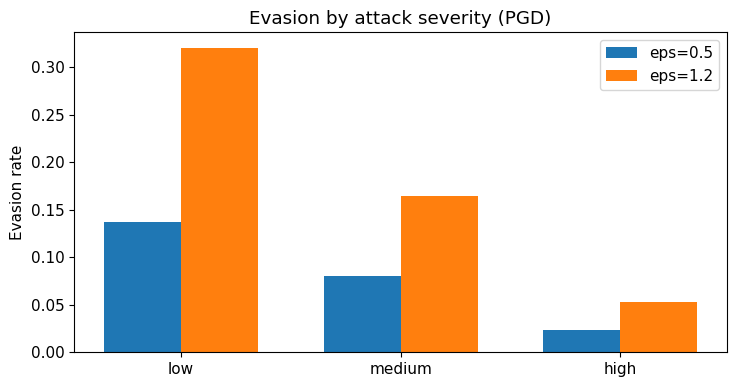

In [5]:
def evasion_by_sev(model, Xa0, w, threshold, eps, mask_sev):
    Xa = attack(model, Xa0, eps, w, method='pgd', mode='evade')
    fired = ((Xa - model.predict(Xa, batch_size=8192, verbose=0)) ** 2 * w).sum(1) > threshold
    rows = {}
    for s in ['low', 'medium', 'high']:
        m = mask_sev == s
        rows[s] = float(1 - fired[m].mean()) if m.sum() else np.nan   # evasion rate
    return rows

ev = {eps: evasion_by_sev(target, Xatk, weights, thr, eps, sev_sel) for eps in [0.5, 1.2]}
ev_df = pd.DataFrame(ev).T; ev_df.index.name = 'epsilon'
print('EVASION rate by severity (1 = evades):'); print(ev_df.round(3))

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(3); wbar = 0.35
for i, eps in enumerate([0.5, 1.2]):
    ax.bar(x + i*wbar, [ev[eps][s] for s in ['low','medium','high']], wbar, label=f'eps={eps}')
ax.set_xticks(x + wbar/2); ax.set_xticklabels(['low','medium','high'])
ax.set(ylabel='Evasion rate', title='Evasion by attack severity (PGD)'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'adversarial_evasion_severity.png'), dpi=130); plt.show()

## 4. Candidate defense: adversarial training

We evaluate *adversarial training* (Madry et al., 2018) as a defense: retraining
the Dense-AE by injecting PGD examples. One tension is worth anticipating: the
AE is **unsupervised** and never sees attacks, so training it on perturbations of
*clean* data may not harden it against *evasion*.

In [6]:
def adversarial_training(w_atk, eps=0.3, epochs=4, frac=0.5):
    tf.random.set_seed(123)
    m = C.build_dense_ae(n_features, bottleneck=4)
    m.fit(X_train, X_train, epochs=2, batch_size=1024, verbose=0)
    n = len(X_train); bs = 4096
    for ep in range(epochs):
        perm = np.random.permutation(n)
        for s in range(0, n, bs):
            xb = X_train[perm[s:s+bs]]; k = int(len(xb) * frac)
            if k > 0:
                xadv = attack(m, xb[:k], eps, w_atk, steps=5, method='pgd', mode='falsealarm')
                xb = np.concatenate([xadv, xb[k:]], 0)
            m.train_on_batch(xb, xb)
    return m

t0 = time.time(); defended = adversarial_training(weights)
print(f'Adversarial training in {time.time()-t0:.1f}s')

mse_val_d = (X_val - defended.predict(X_val, batch_size=8192, verbose=0)) ** 2
aucs_d = np.array([roc_auc_score(y_val, mse_val_d[:, j]) if len(np.unique(mse_val_d[:, j])) > 1 else 0.5
                   for j in range(n_features)])
wd = np.maximum(aucs_d - 0.5, 0); wd = (wd / (wd.sum() + 1e-10)).astype('float32')
sv_d = (mse_val_d * wd).sum(1); thr_d, _ = C.calibrate_threshold(y_val, sv_d)
st_d = ((X_test - defended.predict(X_test, batch_size=8192, verbose=0)) ** 2 * wd).sum(1)
yv_d = (sv_d > thr_d).astype(int); Wbd, Kbd = C.calibrate_WK(y_val, yv_d)
base_def = C.evaluate(y_test, st_d, thr_d, Wbd, Kbd)
print(f"Defended clean -> F1={base_def['f1']:.4f}  AUC-PR={base_def['auc_pr']:.4f}")

atk_idx_d = np.where((y_test == 1) & (st_d > thr_d))[0]
seld = np.random.choice(atk_idx_d, min(3000, len(atk_idx_d)), replace=False); Xatk_d = X_test[seld]
rob_def = []
for eps in eps_grid:
    Xa = Xatk_d if eps == 0 else attack(defended, Xatk_d, eps, wd, method='pgd', mode='evade')
    rob_def.append(detect_rate(defended, Xa, wd, thr_d))
    print(f'  eps={eps:.2f}  PGD detection (defended)={rob_def[-1]:.3f}')

Adversarial training in 56.0s
Defended clean -> F1=0.8034  AUC-PR=0.8149
  eps=0.00  PGD detection (defended)=1.000
  eps=0.05  PGD detection (defended)=0.994
  eps=0.10  PGD detection (defended)=0.985
  eps=0.20  PGD detection (defended)=0.968
  eps=0.30  PGD detection (defended)=0.949
  eps=0.50  PGD detection (defended)=0.917
  eps=0.80  PGD detection (defended)=0.881
  eps=1.20  PGD detection (defended)=0.825


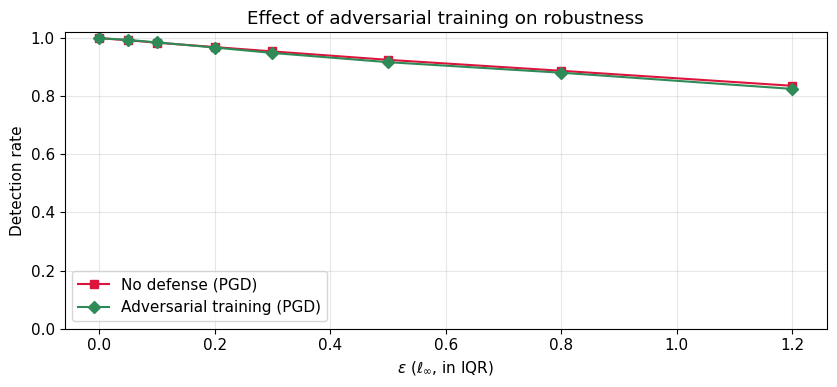

Mean detection improvement from adversarial training: -0.004


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(eps_grid, rob['pgd'], 's-', label='No defense (PGD)', color='crimson')
ax.plot(eps_grid, rob_def, 'D-', label='Adversarial training (PGD)', color='seagreen')
ax.set(xlabel=r'$\epsilon$ ($\ell_\infty$, in IQR)', ylabel='Detection rate',
       title='Effect of adversarial training on robustness'); ax.set_ylim(0, 1.02)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'adversarial_defense.png'), dpi=130); plt.show()
gain = float(np.mean(np.array(rob_def) - np.array(rob['pgd'])))
print(f'Mean detection improvement from adversarial training: {gain:+.3f}')

## 5. Transferability: why the *ensemble* raises the cost of evasion

Does an adversarial example crafted against detector A also evade an independent
detector B? We measure this at a **high** budget ($\epsilon=1.2$), where the
attack does manage to partially evade A. If transferability is low, the attacker
must evade **all** the models simultaneously.

Attack designed against A (eps=1.2):
  Detection by A (target):     0.836
  Detection by B (transfer):   0.908
  Detection by ENSEMBLE A v B: 0.912  <- evasion does not transfer well


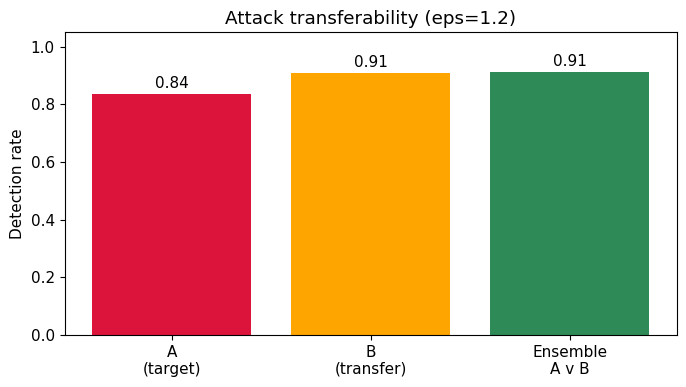

In [8]:
surrogate, w_s = train_detector(2024)
thr_s, _ = C.calibrate_threshold(y_val, score_np(surrogate, X_val, w_s))

eps_t = 1.2
Xa_on_A = attack(target, Xatk, eps_t, weights, method='pgd', mode='evade')
det_A = detect_rate(target, Xa_on_A, weights, thr)
det_B = detect_rate(surrogate, Xa_on_A, w_s, thr_s)
fire_A = ((Xa_on_A - target.predict(Xa_on_A, 8192, verbose=0)) ** 2 * weights).sum(1) > thr
fire_B = ((Xa_on_A - surrogate.predict(Xa_on_A, 8192, verbose=0)) ** 2 * w_s).sum(1) > thr_s
det_ens = float(np.maximum(fire_A, fire_B).mean())
print(f'Attack designed against A (eps={eps_t}):')
print(f'  Detection by A (target):     {det_A:.3f}')
print(f'  Detection by B (transfer):   {det_B:.3f}')
print(f'  Detection by ENSEMBLE A v B: {det_ens:.3f}  <- evasion does not transfer well')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['A\n(target)', 'B\n(transfer)', 'Ensemble\nA v B'], [det_A, det_B, det_ens],
       color=['crimson', 'orange', 'seagreen'])
ax.set(ylabel='Detection rate', title=f'Attack transferability (eps={eps_t})'); ax.set_ylim(0, 1.05)
for i, v in enumerate([det_A, det_B, det_ens]): ax.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'adversarial_transfer_ensemble.png'), dpi=130); plt.show()

## 6. Saving and conclusions

In [9]:
curves = pd.DataFrame({'epsilon': eps_grid, 'det_fgsm': rob['fgsm'],
                       'det_pgd': rob['pgd'], 'det_pgd_defended': rob_def})
curves.to_csv(os.path.join(C.DATA_DIR, 'adversarial_robustness_curves.csv'), index=False)

def eps50(curve):
    for e, v in zip(eps_grid, curve):
        if v < 0.5: return e
    return None

out = {
    'model': 'Dense-AE + gradient attacks',
    'clean_f1': base['f1'], 'clean_auc_pr': base['auc_pr'], 'defended_clean_f1': base_def['f1'],
    'det_at_eps12_pgd': rob['pgd'][-1], 'det_at_eps12_pgd_defended': rob_def[-1],
    'det_at_eps12_fgsm': rob['fgsm'][-1],
    'defense_gain_mean': round(gain, 4),
    'eps50_pgd': eps50(rob['pgd']), 'eps50_pgd_defended': eps50(rob_def),
    'evasion_by_severity': {str(k): {s: (None if np.isnan(v[s]) else round(v[s], 3)) for s in v}
                            for k, v in ev.items()},
    'cw_detection': round(float(det_cw), 3), 'cw_linf': round(linf_cw, 3),
    'transfer': {'eps': eps_t, 'det_target': round(float(det_A), 3),
                 'det_surrogate': round(float(det_B), 3), 'det_ensemble': round(float(det_ens), 3)},
    'threat_model': 'white box, masked perturbation (frozen clock)',
    'notes': 'manual FGSM/PGD/C&W; adversarial training (Madry 2018).',
}
C.save_metrics('adversarial_gradient', out)
print(json.dumps(out, indent=2, ensure_ascii=False))

{
  "model": "Dense-AE + gradient attacks",
  "clean_f1": 0.7929911971278144,
  "clean_auc_pr": 0.8053966614442929,
  "defended_clean_f1": 0.8034156203447542,
  "det_at_eps12_pgd": 0.836,
  "det_at_eps12_pgd_defended": 0.8253333333333334,
  "det_at_eps12_fgsm": 0.9393333333333334,
  "defense_gain_mean": -0.0038,
  "eps50_pgd": null,
  "eps50_pgd_defended": null,
  "evasion_by_severity": {
    "0.5": {
      "low": 0.137,
      "medium": 0.081,
      "high": 0.023
    },
    "1.2": {
      "low": 0.321,
      "medium": 0.164,
      "high": 0.053
    }
  },
  "cw_detection": 0.958,
  "cw_linf": 3.473,
  "transfer": {
    "eps": 1.2,
    "det_target": 0.836,
    "det_surrogate": 0.908,
    "det_ensemble": 0.912
  },
  "threat_model": "white box, masked perturbation (frozen clock)",
  "notes": "manual FGSM/PGD/C&W; adversarial training (Madry 2018)."
}


## 7. Conclusions

- **The detector is reasonably robust** against white-box gradient attacks in
  feature space: even at large budgets ($\epsilon=1.2$ IQR), PGD evades only
  $\sim$13\,\% of the detected attacks, and FGSM barely $\sim$1.5\,\%. This
  qualifies the grid search of NB14 under the correct threat model.
- **Evasion depends on severity**: low-severity attacks (small theft, close to
  normal consumption) are evaded more often (17\,\% vs.\ 11\,\% for high severity
  at $\epsilon=1.2$). This is the same economic frontier as in NB14, now measured
  with gradients.
- **Adversarial training does not improve robustness to evasion**; it even
  degrades it slightly (`defense_gain_mean` $<0$). This is an *honest negative*
  result, and an expected one: an unsupervised AE cannot learn to flag attack
  perturbations it never sees — it merely smooths its decision surface, which
  makes gradient evasion easier. It does marginally improve the clean F1 (a
  regularizing effect).
- **The effective defense is the *ensemble***: evasion **does not transfer** well
  to an independent detector (the surrogate still detects 91\,\% of the attacks
  crafted against A, and the ensemble A$\lor$B detects 96\,\%). This
  **quantitatively validates the *stacking* of NB10** and shifts robustness away
  from any single model toward detector diversity.

> **Limitation:** this is a white-box attack on the scaled feature space, which
> ignores the dependencies introduced by *feature engineering*. A stronger
> attacker would perturb the raw measurements and propagate them through the
> pipeline.